# Planning a telescope observation

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

%matplotlib inline
%config InlineBackend.figure_format='retina'

random_state = np.random.RandomState(seed=10)

In [2]:
cloudy=0
clear=1

current=cloudy

weather tomorrow will depend on weather today:
- p(clear tomorrow|clear today) = 0.9
- p(clear tomorrow|cloudy today) = 0.5

In [3]:
N=50000

def weather(current, N):
    
    weather=[current]
    
    for i in range(1, N):
        x = np.random.uniform(0,1)

        if current == clear:
            if x < 0.9: 
                current = clear
            else:
                current = cloudy
                
        elif current == cloudy:
            if x < 0.5: 
                current = clear
            else:
                current = cloudy

        weather.append(current)
        
    return np.array(weather)

In [4]:
weather = weather(current,N)
probability = np.mean(weather)
print('After N days, p(clear)=',probability)

After N days, p(clear)= 0.83188


In [5]:
weather

array([0, 0, 1, ..., 1, 1, 1])

In [6]:
weather.size

50000

In [7]:
np.arange(weather.size) #Returns evenly spaced values within a given interval

array([    0,     1,     2, ..., 49997, 49998, 49999])

In [8]:
np.arange(weather.size)+1

array([    1,     2,     3, ..., 49998, 49999, 50000])

In [9]:
np.cumsum(weather)

array([    0,     0,     1, ..., 41592, 41593, 41594])

cumulative fraction of clear days over the number of days so far

In [10]:
np.cumsum(weather)/(np.arange(weather.size)+1)

array([0.        , 0.        , 0.33333333, ..., 0.83187327, 0.83187664,
       0.83188   ])

Trace-plot: the cumulative fraction of clear days over the number of days so far vs number of days

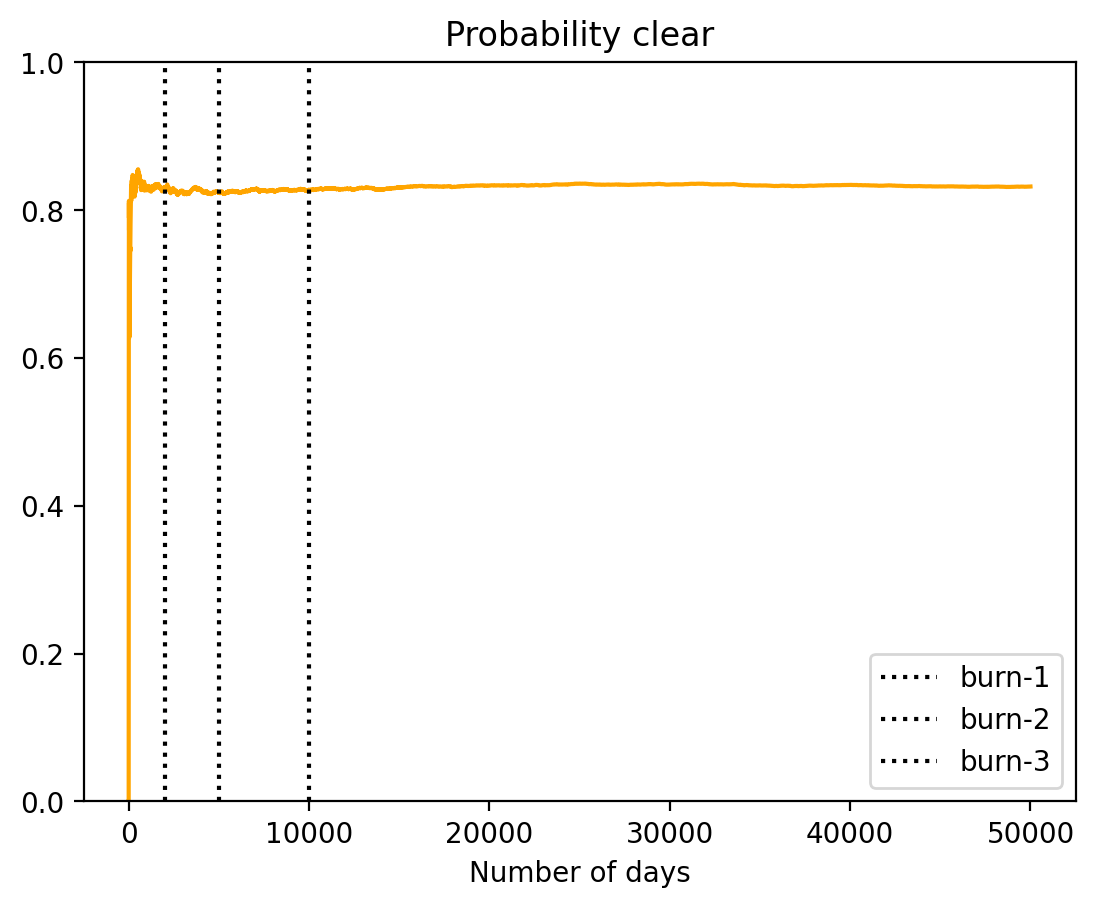

In [11]:
prob = np.cumsum(weather)/(np.arange(weather.size)+1)
plt.plot(prob, color='orange')

plt.axvline(2000, ls='dotted', color='black', label='burn-1')
plt.axvline(5000, ls='dotted', color='black', label='burn-2')
plt.axvline(10000, ls='dotted', color='black', label='burn-3')

plt.ylim(0,1)
plt.xlabel('Number of days')
plt.title('Probability clear')
plt.legend()
plt.show()

In [12]:
median = np.median(prob)
sigma = astroMLstats.sigmaG(prob) # Compute the rank-based estimate of the standard deviation

print('Median:', median)
print('Sigma:', sigma)

Median: 0.8325270411970614
Sigma: 0.003046878546548961


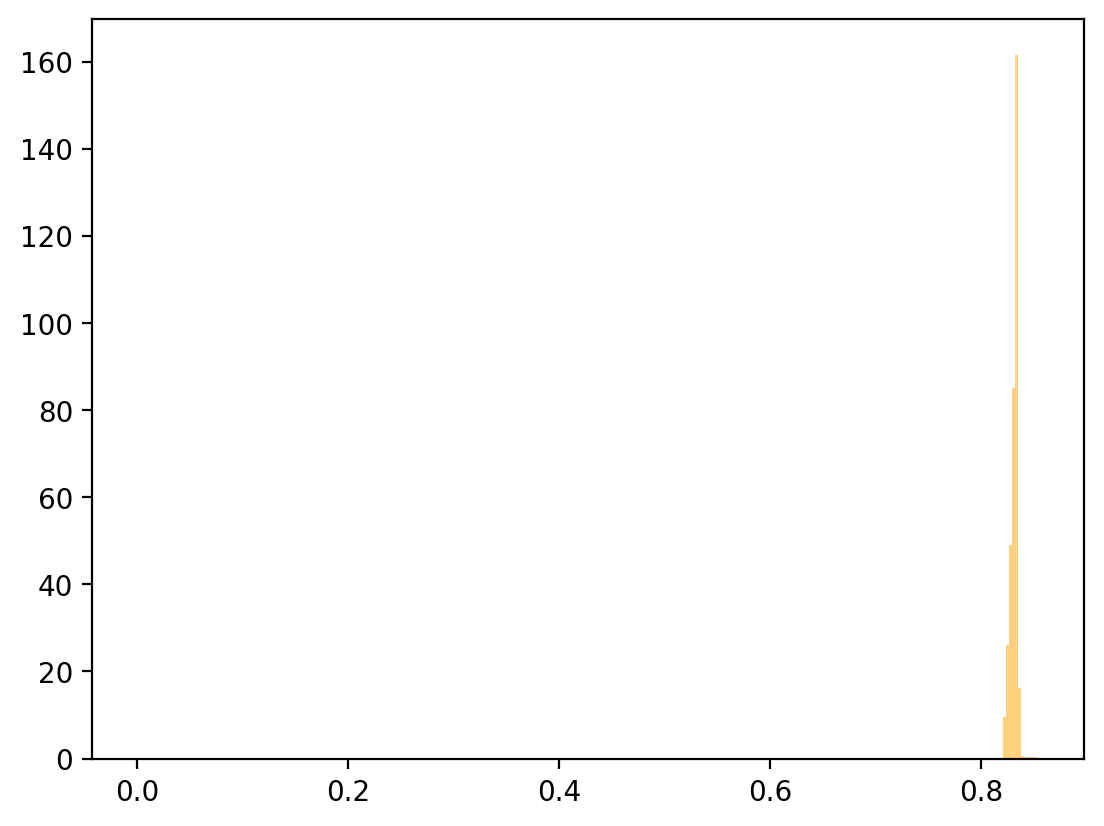

In [13]:
plt.hist(prob, bins=300, density=True,color='orange', alpha=0.5);

The distribution shows very long tails, let's try with chopping off the initial points where the chain is not stationaty yet (try with different burn-in)

(0.0, 800.0)

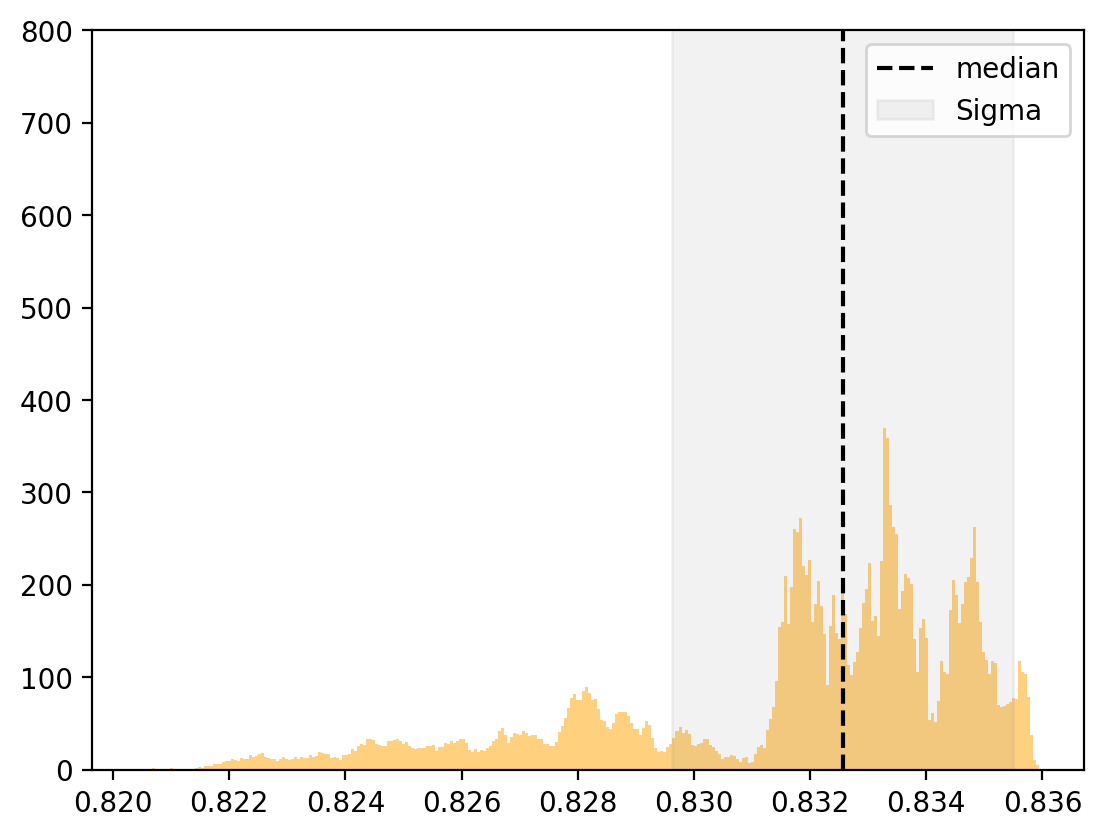

In [14]:
burn = 2000

plt.hist(prob[burn:], bins=300, color='orange',alpha=0.5, density=True);

median = np.median(prob[burn:])
sigma = astroMLstats.sigmaG(prob[burn:])

plt.axvline(median, color='black', ls='dashed', label='median')
y_grid = np.linspace(0,1300,100)
plt.fill_betweenx(y_grid, median-sigma, median+sigma, color='grey', alpha=0.1, label="Sigma")
plt.legend()
plt.ylim(0,800)

(0.0, 800.0)

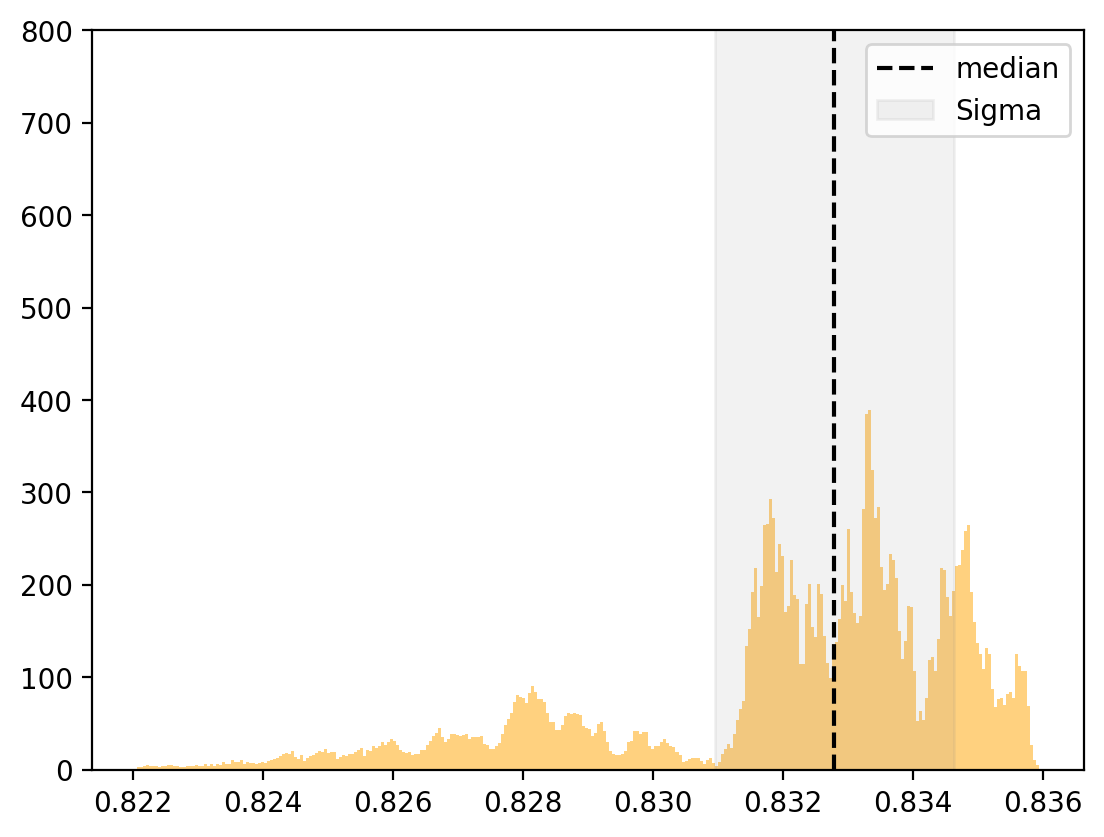

In [15]:
burn = 5000

plt.hist(prob[burn:], bins=300, color='orange',alpha=0.5, density=True);

median = np.median(prob[burn:])
sigma = astroMLstats.sigmaG(prob[burn:])

plt.axvline(median, color='black', ls='dashed', label='median')
y_grid = np.linspace(0,1300,100)
plt.fill_betweenx(y_grid, median-sigma, median+sigma, color='grey', alpha=0.1, label="Sigma")
plt.legend()
plt.ylim(0,800)

(0.0, 800.0)

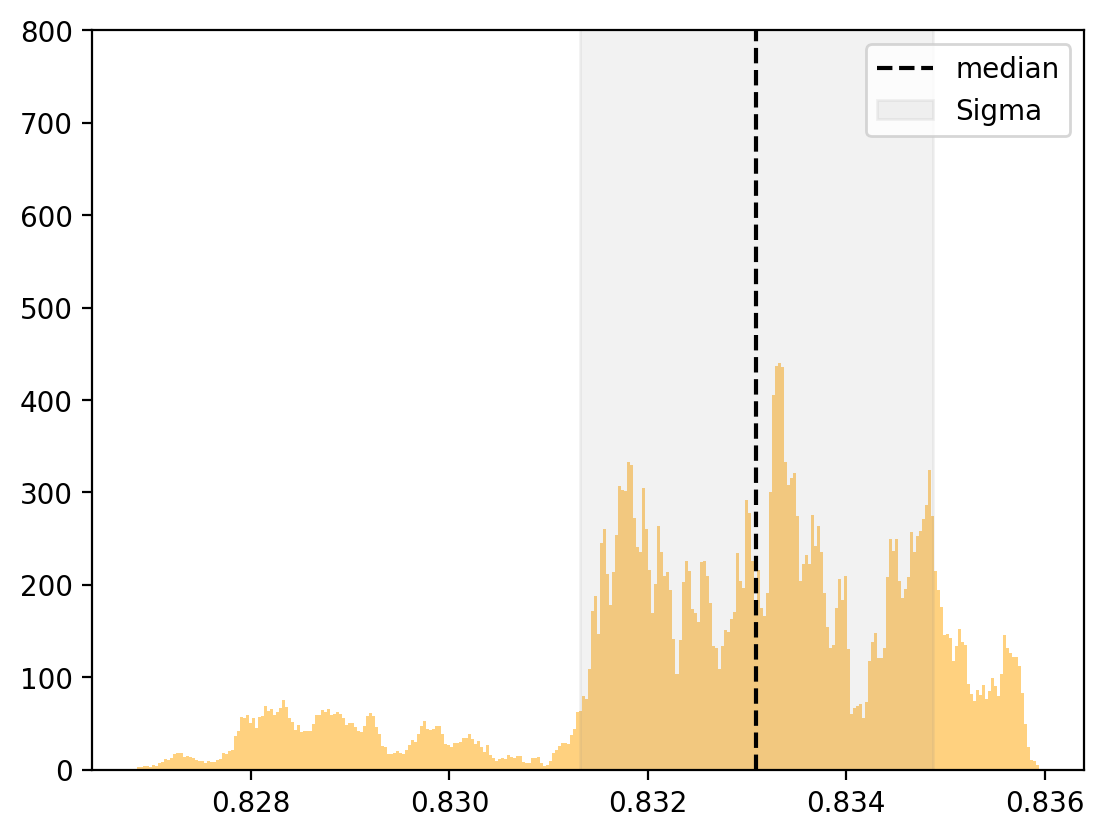

In [16]:
burn = 10000

plt.hist(prob[burn:], bins=300, color='orange',alpha=0.5, density=True);

median = np.median(prob[burn:])
sigma = astroMLstats.sigmaG(prob[burn:])

plt.axvline(median, color='black', ls='dashed', label='median')
y_grid = np.linspace(0,1400,100)
plt.fill_betweenx(y_grid, median-sigma, median+sigma, color='grey', alpha=0.1, label="Sigma")
plt.legend()
plt.ylim(0,800)

The more points I discard, the shorter the tails of the distribution